# Cross-Model Comparison — Validation Set

Loads every available trained model and evaluates on the same val set. Produces:
- `outputs/comparison/comparison.csv` — side-by-side metrics table
- `outputs/comparison/comparison_dashboard.png` — grouped bar charts
- `outputs/comparison/roc_overlay.png` — overlay of all ROC curves
- `outputs/comparison/winner.json` — model with highest composite score

Run after all 3 training notebooks complete (or with whichever models have weights).


## Setup

In [8]:
import os, sys, gc, json, time
from pathlib import Path
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix, f1_score, roc_curve,
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
VAL_FRAC = 0.15
IMG_SIZE = 512
BATCH_SIZE = 8

import random
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)


## Dataset (same val split as training)

In [13]:
INPUT_DIR = '/kaggle/input/competitions/recodai-luc-scientific-image-forgery-detection'
TRAIN_IMGS = f'{INPUT_DIR}/train_images'
TRAIN_MASKS = f'{INPUT_DIR}/train_masks'
SUPP_IMGS = f'{INPUT_DIR}/supplemental_images'
SUPP_MASKS = f'{INPUT_DIR}/supplemental_masks'

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

val_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])


def load_mask(path, h, w):
    m = np.load(path)
    if m.ndim == 3:
        m = m.max(axis=0)
    if m.shape != (h, w):
        m = cv2.resize(m.astype(np.float32), (w, h), interpolation=cv2.INTER_NEAREST)
    return (m > 0).astype(np.float32)


class ForgeryDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        s = self.samples[idx]
        img = cv2.cvtColor(cv2.imread(s['img']), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        mask = load_mask(s['mask'], h, w) if s['label'] == 1 and s['mask'] else np.zeros((h, w), np.float32)
        if self.transform:
            out = self.transform(image=img, mask=mask)
            img, mask = out['image'], out['mask']
        return img, torch.tensor(s['label'], dtype=torch.float32), mask.unsqueeze(0)


def build_samples():
    samples, uids = [], []
    auth_dir = f'{TRAIN_IMGS}/authentic'
    forg_dir = f'{TRAIN_IMGS}/forged'
    auth_uids = {os.path.splitext(f)[0] for f in os.listdir(auth_dir) if f.endswith('.png')}
    forg_uids = {os.path.splitext(f)[0] for f in os.listdir(forg_dir) if f.endswith('.png')}
    for uid in sorted(auth_uids & forg_uids):
        uids.append(uid)
        samples.append({'uid': uid, 'img': f'{auth_dir}/{uid}.png', 'label': 0, 'mask': None})
        mp = f'{TRAIN_MASKS}/{uid}.npy'
        if os.path.exists(mp):
            samples.append({'uid': uid, 'img': f'{forg_dir}/{uid}.png', 'label': 1, 'mask': mp})
    if os.path.isdir(SUPP_IMGS):
        for fname in sorted(os.listdir(SUPP_IMGS)):
            if not fname.endswith('.png'):
                continue
            uid = os.path.splitext(fname)[0]
            mp = f'{SUPP_MASKS}/{uid}.npy'
            if os.path.exists(mp):
                samples.append({'uid': uid, 'img': f'{SUPP_IMGS}/{fname}', 'label': 1, 'mask': mp, 'supplemental': True})
    return samples, uids


all_samples, all_uids = build_samples()
shuffled = sorted(all_uids)
random.shuffle(shuffled)
n_val = int(VAL_FRAC * len(shuffled))
val_uids = set(shuffled[:n_val])
val_samples = [s for s in all_samples if s['uid'] in val_uids]

val_ds = ForgeryDataset(val_samples, val_tf)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)
print(f'Val samples: {len(val_samples)}')


Val samples: 713


## Architecture (shared)

In [20]:
# Architecture (same as training notebooks)
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        mid = max(channels // reduction, 4)
        self.channel_fc = nn.Sequential(
            nn.Linear(channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, channels, bias=False),
        )
        self.spatial_conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
    def forward(self, x):
        b, c = x.shape[:2]
        avg = self.channel_fc(F.adaptive_avg_pool2d(x, 1).view(b, c)).view(b, c, 1, 1)
        mx  = self.channel_fc(F.adaptive_max_pool2d(x, 1).view(b, c)).view(b, c, 1, 1)
        x = x * torch.sigmoid(avg + mx)
        spatial = torch.cat([x.mean(1, keepdim=True), x.max(1, keepdim=True)[0]], dim=1)
        x = x * torch.sigmoid(self.spatial_conv(spatial))
        return x


class ConvBNReLU(nn.Sequential):
    def __init__(self, in_c, out_c, k=3, p=1):
        super().__init__(
            nn.Conv2d(in_c, out_c, k, padding=p, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )


class DecoderBlock(nn.Module):
    def __init__(self, in_c, skip_c, out_c):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv = nn.Sequential(
            ConvBNReLU(in_c + skip_c, out_c),
            ConvBNReLU(out_c, out_c),
        )
        self.cbam = CBAM(out_c)
    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None:
            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
            x = torch.cat([x, skip], dim=1)
        return self.cbam(self.conv(x))


class FiveLevelUNet(nn.Module):
    def __init__(self, encoder, ch):
        super().__init__()
        self.encoder = encoder
        self.d4 = DecoderBlock(ch[4], ch[3], 256)
        self.d3 = DecoderBlock(256,   ch[2], 128)
        self.d2 = DecoderBlock(128,   ch[1],  64)
        self.d1 = DecoderBlock(64,    ch[0],  32)
        self.d0 = DecoderBlock(32,        0,  16)
        self.seg_head  = nn.Conv2d(16, 1, 1)
        self.aux4_head = nn.Conv2d(256, 1, 1)
        self.aux3_head = nn.Conv2d(128, 1, 1)
        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(ch[4], 512), nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 1),
        )
    def forward(self, x):
        f0, f1, f2, f3, f4 = self.encoder(x)
        cls_out = self.cls_head(f4)
        d4 = self.d4(f4, f3)
        d3 = self.d3(d4, f2)
        d2 = self.d2(d3, f1)
        d1 = self.d1(d2, f0)
        d0 = self.d0(d1)
        return cls_out, self.seg_head(d0), self.aux4_head(d4), self.aux3_head(d3)


class FourLevelUNet(nn.Module):
    def __init__(self, encoder, ch, channels_last_input=False):
        super().__init__()
        self.encoder = encoder
        self.expected_channels = list(ch)
        self.channels_last_input = channels_last_input
        self.d3 = DecoderBlock(ch[3], ch[2], 256)
        self.d2 = DecoderBlock(256,   ch[1], 128)
        self.d1 = DecoderBlock(128,   ch[0],  64)
        self.d0a = DecoderBlock(64, 0, 32)
        self.d0b = DecoderBlock(32, 0, 16)
        self.seg_head  = nn.Conv2d(16, 1, 1)
        self.aux3_head = nn.Conv2d(256, 1, 1)
        self.aux2_head = nn.Conv2d(128, 1, 1)
        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(ch[3], 512), nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 1),
        )
    @staticmethod
    def _ensure_nchw(t, expected_c):
        if t.dim() != 4:
            return t
        if t.shape[1] == expected_c:
            return t
        if t.shape[-1] == expected_c:
            return t.permute(0, 3, 1, 2).contiguous()
        return t
    def forward(self, x):
        feats = self.encoder(x)
        feats = [self._ensure_nchw(f, c)
                 for f, c in zip(feats, self.expected_channels)]
        f0, f1, f2, f3 = feats
        cls_out = self.cls_head(f3)
        d3 = self.d3(f3, f2)
        d2 = self.d2(d3, f1)
        d1 = self.d1(d2, f0)
        d0a = self.d0a(d1)
        d0  = self.d0b(d0a)
        seg = self.seg_head(d0)
        if seg.shape[-2:] != x.shape[-2:]:
            seg = F.interpolate(seg, size=x.shape[-2:], mode='bilinear', align_corners=False)
        return cls_out, seg, self.aux3_head(d3), self.aux2_head(d2)


def build_eval_model(name):
    if name == 'efficientnet_b4':
        enc = timm.create_model('efficientnet_b4', pretrained=False, features_only=True)
        return FiveLevelUNet(enc, enc.feature_info.channels())
    if name == 'convnext_tiny':
        enc = timm.create_model('convnext_tiny', pretrained=False, features_only=True)
        return FourLevelUNet(enc, enc.feature_info.channels(), channels_last_input=False)
    if name == 'swin_v2_tiny':
        enc = timm.create_model('swinv2_tiny_window8_256', pretrained=False,
                                features_only=True, img_size=512)
        return FourLevelUNet(enc, enc.feature_info.channels(), channels_last_input=True)
    if name == 'swin_v2_base':
        enc = timm.create_model('swinv2_base_window8_256', pretrained=False,
                                features_only=True, img_size=512)
        return FourLevelUNet(enc, enc.feature_info.channels(), channels_last_input=True)
    raise ValueError(f'Unknown: {name}')


## Evaluation across all available models

In [21]:
import glob

# Auto-discover all *.pt under /kaggle/input/models/, /kaggle/working/outputs/,
# and the local /kaggle/working tree. Detect architecture from state dict +
# filename hints. Robust to whatever upload pattern Kaggle gave you.

DISPLAY_NAMES = {
    'efficientnet_b4': 'EfficientNet-B4',
    'convnext_tiny':   'ConvNeXt-Tiny',
    'swin_v2_tiny':    'Swin-V2-Tiny',
    'swin_v2_base':    'Swin-V2-Base',
    'resnet50':        'ResNet-50',
}

# Per-architecture default thresholds (used when checkpoint has no metadata)
DEFAULT_THRESHOLDS = {
    'efficientnet_b4': 0.40,
    'resnet50':        0.50,
    'convnext_tiny':   0.55,
    'swin_v2_tiny':    0.51,
    'swin_v2_base':    0.54,
}


def _detect_arch_from_state(state):
    if not isinstance(state, dict) or not state:
        return None
    has_d4   = any(k.startswith('d4.') or k.startswith('aux4_head') for k in state)
    has_d0ab = any(k.startswith('d0a.') or k.startswith('d0b.') or
                   k.startswith('aux2_head') for k in state)
    cls_w = state.get('cls_head.3.weight')
    cls_in_dim = cls_w.shape[1] if (cls_w is not None and cls_w.dim() == 2) else None

    if has_d4:
        if 'encoder.conv_stem.weight' in state:
            return 'efficientnet_b4'
        if 'encoder.conv1.weight' in state and 'encoder.layer1.0.conv1.weight' in state:
            return 'resnet50'
        if cls_in_dim == 448:  return 'efficientnet_b4'
        if cls_in_dim == 2048: return 'resnet50'
    elif has_d0ab:
        if any('encoder.stages.' in k and 'conv_dw' in k for k in state):
            return 'convnext_tiny'
        if any('encoder.layers.' in k and 'attn' in k for k in state):
            return 'swin_v2_base' if cls_in_dim == 1024 else 'swin_v2_tiny'
        if cls_in_dim == 1024: return 'swin_v2_base'
        if cls_in_dim == 768:  return 'convnext_tiny'
    return None


def _detect_arch(ckpt, filename):
    candidates = [
        ('efficientnet_b4', ('efficientnet_b4', 'efficientnet-b4', 'effnet')),
        ('swin_v2_base',    ('swinv2_base', 'swin_v2_base', 'swin-v2-base', 'swinv2-base')),
        ('swin_v2_tiny',    ('swinv2_tiny', 'swin_v2_tiny', 'swin-v2-tiny', 'swinv2-tiny', 'swin')),
        ('convnext_tiny',   ('convnext_tiny', 'convnext-tiny', 'convnext')),
        ('resnet50',        ('resnet50', 'resnet-50', 'rn50')),
    ]
    if isinstance(ckpt, dict):
        for field in ('backbone', 'architecture'):
            val = str(ckpt.get(field, '')).lower()
            if not val:
                continue
            for arch_id, keys in candidates:
                if any(k in val for k in keys):
                    return arch_id
    state = ckpt
    if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
        state = ckpt['model_state_dict']
    arch_id = _detect_arch_from_state(state)
    if arch_id is not None:
        return arch_id
    fn = filename.lower()
    for arch_id, keys in candidates:
        if any(k in fn for k in keys):
            return arch_id
    return None


def _remap_state_dict(state):
    out = {}
    for k, v in state.items():
        nk = k[7:] if k.startswith('module.') else k
        nk = nk.replace('.cbam.fc.',      '.cbam.channel_fc.')
        nk = nk.replace('.cbam.spatial.', '.cbam.spatial_conv.')
        out[nk] = v
    return out


# ── Discover .pt files under common Kaggle locations ─────────────────────────
SCAN_ROOTS = ['/kaggle/input/models', '/kaggle/working/outputs', '/kaggle/working']
all_pts = set()
for root in SCAN_ROOTS:
    if os.path.isdir(root):
        # Recursive glob, up to 6 levels deep
        for depth_glob in ('*.pt', '*/*.pt', '*/*/*.pt', '*/*/*/*.pt',
                           '*/*/*/*/*.pt', '*/*/*/*/*/*.pt'):
            all_pts.update(glob.glob(os.path.join(root, depth_glob)))

# Identify each
available = {}     # arch_id -> (path, threshold)
for path in sorted(all_pts):
    try:
        ckpt = torch.load(path, map_location='cpu', weights_only=False)
    except Exception as exc:
        print(f'  [skip] {path}: {exc}')
        continue
    arch_id = _detect_arch(ckpt, os.path.basename(path))
    if arch_id is None:
        print(f'  [skip] {path}: cannot determine architecture')
        continue
    # Threshold: saved or arch default
    if isinstance(ckpt, dict) and ckpt.get('cls_threshold') is not None:
        thr = float(ckpt['cls_threshold'])
    else:
        thr = DEFAULT_THRESHOLDS.get(arch_id, 0.50)
    # If we already saw this arch_id, prefer the bundle (with metadata) over raw best.pt
    if arch_id in available:
        prev_path, _ = available[arch_id]
        prev_has_meta = isinstance(torch.load(prev_path, map_location='cpu', weights_only=False), dict)                         and 'model_state_dict' in torch.load(prev_path, map_location='cpu', weights_only=False)
        cur_has_meta  = isinstance(ckpt, dict) and 'model_state_dict' in ckpt
        if cur_has_meta and not prev_has_meta:
            available[arch_id] = (path, thr)
    else:
        available[arch_id] = (path, thr)

print(f'Found {len(available)} models for comparison:')
for n, (p, t) in available.items():
    print(f'  {n:18s} thr={t:.2f}  {p}')


@torch.no_grad()
def eval_one(model, loader):
    model.train(False)
    y_true, y_prob = [], []
    seg_probs, masks_all = [], []
    for imgs, labels, masks in tqdm(loader, leave=False):
        imgs = imgs.to(DEVICE)
        cls_out, seg_out, _, _ = model(imgs)
        probs = torch.sigmoid(cls_out).squeeze(1).cpu().numpy()
        sp = torch.sigmoid(seg_out).squeeze(1).cpu().numpy()
        m = masks.squeeze(1).numpy()
        y_true.extend(labels.numpy())
        y_prob.extend(probs)
        for i in range(len(labels)):
            if labels[i] == 1:
                seg_probs.append(sp[i])
                masks_all.append(m[i])
    return np.array(y_true), np.array(y_prob), seg_probs, masks_all


def metrics_for(y_true, y_prob, seg_probs, masks_all, thr_hint=None):
    # Sweep threshold for best F1, but bias toward the saved/expected hint
    best_thr, best_f1 = 0.5, 0.0
    for thr in np.arange(0.05, 0.95, 0.01):
        preds = (y_prob > thr).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, float(thr)
    dices = []
    for sp, gt in zip(seg_probs, masks_all):
        pb = (sp > best_thr).astype(np.float32)
        inter = (pb * gt).sum()
        dices.append(2 * inter / (pb.sum() + gt.sum() + 1e-7))
    y_pred = (y_prob > best_thr).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'threshold':     float(best_thr),
        'accuracy':      float(accuracy_score(y_true, y_pred)),
        'auc':           float(roc_auc_score(y_true, y_prob)),
        'precision':     float(tp / (tp + fp + 1e-7)),
        'forged_recall': float(tp / (tp + fn + 1e-7)),
        'specificity':   float(tn / (tn + fp + 1e-7)),
        'f1':            float(2*tp / (2*tp + fp + fn + 1e-7)),
        'mean_dice':     float(np.mean(dices)) if dices else 0.0,
    }


results = {}
roc_curves = {}
for name, (path, hint_thr) in available.items():
    print(f'\n=== {DISPLAY_NAMES.get(name, name)}  (file: {os.path.basename(path)}) ===')
    model = build_eval_model(name).to(DEVICE)
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    state = ckpt['model_state_dict'] if (isinstance(ckpt, dict) and 'model_state_dict' in ckpt) else ckpt
    state = _remap_state_dict(state)
    missing, unexpected = model.load_state_dict(state, strict=False)
    print(f'  load: missing={len(missing)} unexpected={len(unexpected)}')
    model.train(False)

    yt, yp, sp, mm = eval_one(model, val_loader)
    m = metrics_for(yt, yp, sp, mm, thr_hint=hint_thr)
    m['composite'] = 0.4 * m['auc'] + 0.3 * m['forged_recall'] + 0.3 * m['mean_dice']
    results[name] = m
    fpr, tpr, _ = roc_curve(yt, yp)
    roc_curves[name] = (fpr, tpr, m['auc'])

    for k, v in m.items():
        print(f'  {k:18s}: {v:.4f}')

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

OUT_DIR = Path('/kaggle/working/outputs/comparison')
OUT_DIR.mkdir(parents=True, exist_ok=True)


Found 4 models for comparison:
  convnext_tiny      thr=0.55  /kaggle/input/models/jayavikramprakash/best1/pytorch/default/1/best1.pt
  swin_v2_tiny       thr=0.51  /kaggle/input/models/jayavikramprakash/best2/pytorch/default/1/best2.pt
  swin_v2_base       thr=0.54  /kaggle/input/models/jayavikramprakash/best3/pytorch/default/1/best3.pt
  efficientnet_b4    thr=0.40  /kaggle/input/models/jayavikramprakash/r2f/pytorch/default/1/final_model_v3.pt

=== ConvNeXt-Tiny  (file: best1.pt) ===
  load: missing=0 unexpected=0


  0%|          | 0/90 [00:00<?, ?it/s]

  threshold         : 0.5500
  accuracy          : 0.8710
  auc               : 0.9421
  precision         : 0.9027
  forged_recall     : 0.8319
  specificity       : 0.9101
  f1                : 0.8659
  mean_dice         : 0.5562
  composite         : 0.7933

=== Swin-V2-Tiny  (file: best2.pt) ===
  load: missing=0 unexpected=0


  0%|          | 0/90 [00:00<?, ?it/s]

  threshold         : 0.5100
  accuracy          : 0.8527
  auc               : 0.9463
  precision         : 0.8351
  forged_recall     : 0.8796
  specificity       : 0.8258
  f1                : 0.8568
  mean_dice         : 0.5755
  composite         : 0.8150

=== Swin-V2-Base  (file: best3.pt) ===
  load: missing=0 unexpected=0


  0%|          | 0/90 [00:00<?, ?it/s]

  threshold         : 0.5400
  accuracy          : 0.8233
  auc               : 0.9157
  precision         : 0.7939
  forged_recall     : 0.8739
  specificity       : 0.7725
  f1                : 0.8320
  mean_dice         : 0.5005
  composite         : 0.7786

=== EfficientNet-B4  (file: final_model_v3.pt) ===
  load: missing=0 unexpected=0


  0%|          | 0/90 [00:00<?, ?it/s]

  threshold         : 0.4000
  accuracy          : 0.7167
  auc               : 0.8433
  precision         : 0.6585
  forged_recall     : 0.9020
  specificity       : 0.5309
  f1                : 0.7612
  mean_dice         : 0.5043
  composite         : 0.7592


## Comparison plots & winner

        model  threshold  accuracy      auc  precision  forged_recall  specificity       f1  mean_dice  composite
ConvNeXt-Tiny       0.55  0.870968 0.942105   0.902736       0.831933     0.910112 0.865889   0.556168   0.793272
 Swin-V2-Tiny       0.51  0.852735 0.946259   0.835106       0.879552     0.825843 0.856753   0.575456   0.815006
 Swin-V2-Base       0.54  0.823282 0.915683   0.793893       0.873950     0.772472 0.832000   0.500545   0.778622


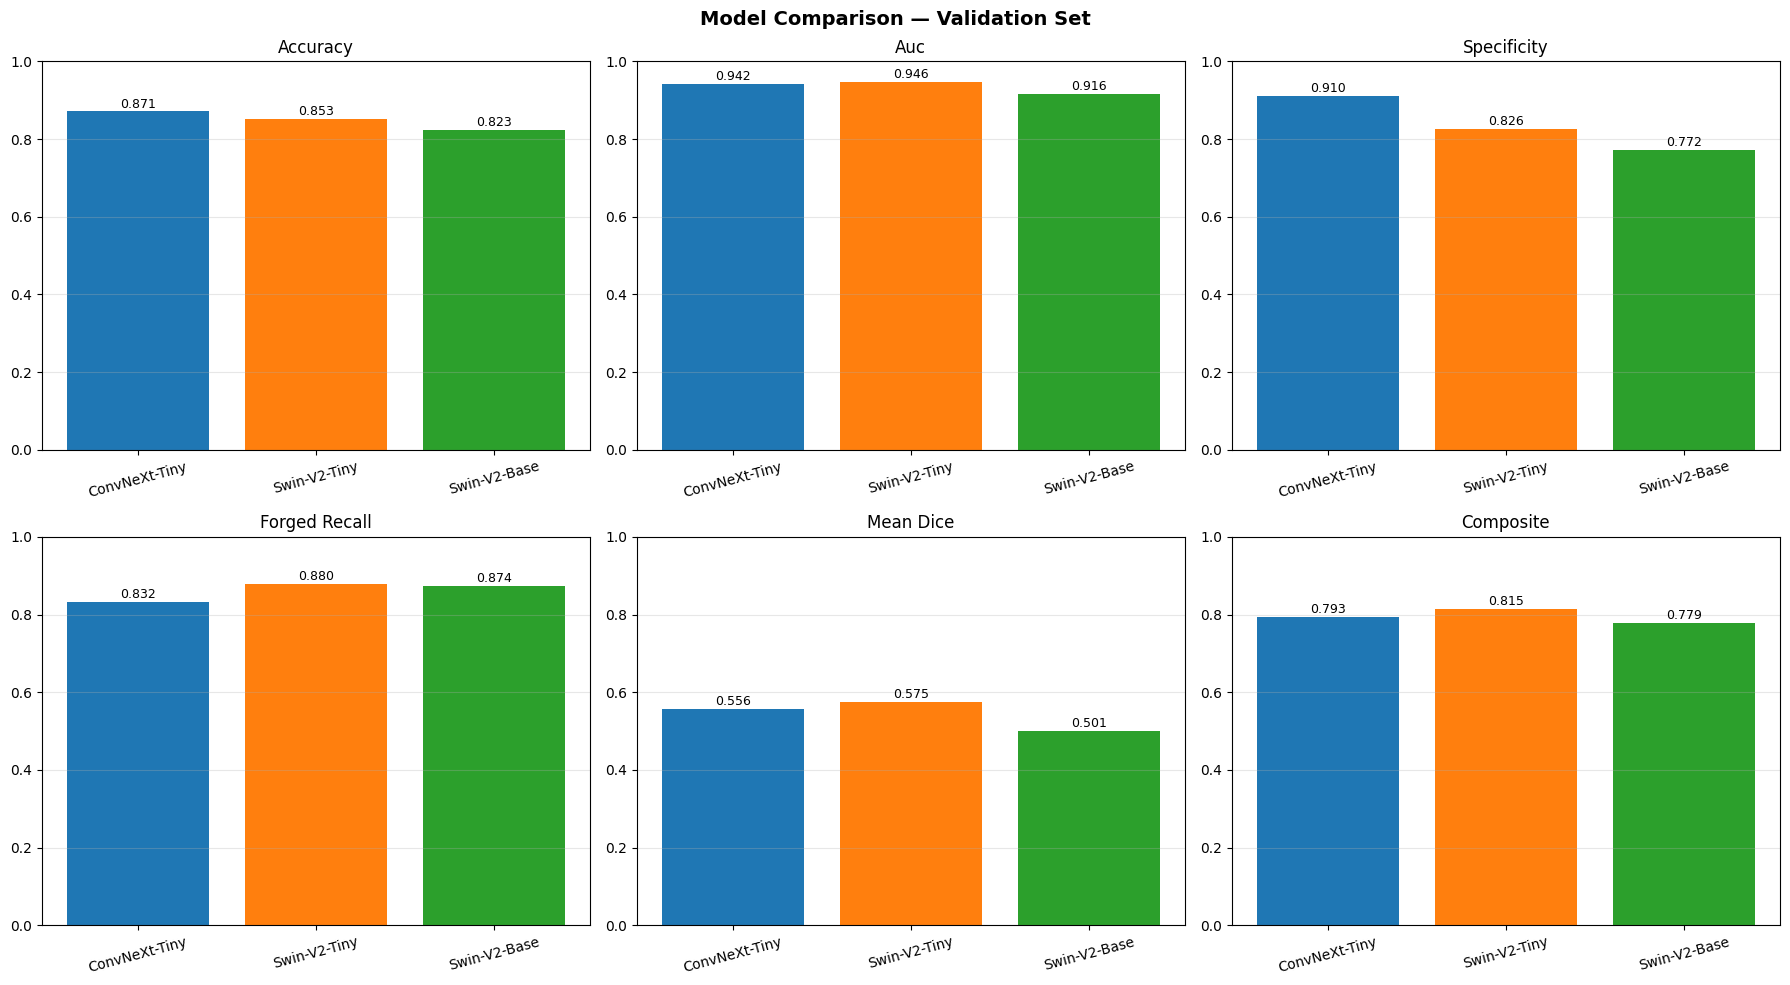

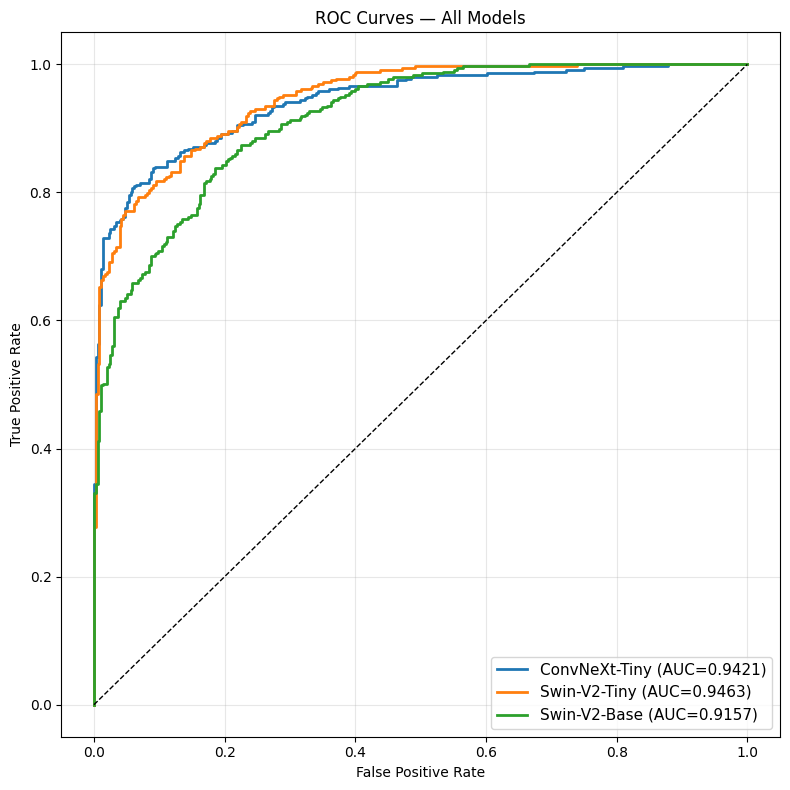


Winner by composite: Swin-V2-Tiny  (composite=0.8150)
Outputs at: /kaggle/working/outputs/comparison


In [19]:
import pandas as pd

# Save CSV
rows = []
for name, m in results.items():
    rows.append({'model': DISPLAY_NAMES[name], **m})
df = pd.DataFrame(rows)
df.to_csv(OUT_DIR / 'comparison.csv', index=False)
print(df.to_string(index=False))

# Bar chart dashboard
metrics_to_plot = ['accuracy', 'auc', 'specificity', 'forged_recall', 'mean_dice', 'composite']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Comparison — Validation Set', fontsize=14, fontweight='bold')
for ax, mkey in zip(axes.flatten(), metrics_to_plot):
    names  = [DISPLAY_NAMES[n] for n in results.keys()]
    values = [results[n][mkey] for n in results.keys()]
    bars = ax.bar(names, values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(names)])
    ax.set_title(mkey.replace('_', ' ').title())
    ax.set_ylim(0, 1.0)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.3f}', ha='center', fontsize=9)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUT_DIR / 'comparison_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

# ROC overlay
fig, ax = plt.subplots(figsize=(8, 8))
for name, (fpr, tpr, auc_val) in roc_curves.items():
    ax.plot(fpr, tpr, lw=2, label=f'{DISPLAY_NAMES[name]} (AUC={auc_val:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'roc_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

# Winner
winner = max(results.items(), key=lambda kv: kv[1]['composite'])
winner_data = {
    'model':     winner[0],
    'display':   DISPLAY_NAMES[winner[0]],
    'composite': winner[1]['composite'],
    'metrics':   winner[1],
}
with open(OUT_DIR / 'winner.json', 'w') as f:
    json.dump(winner_data, f, indent=2)
print(f'\nWinner by composite: {DISPLAY_NAMES[winner[0]]}  (composite={winner[1]["composite"]:.4f})')
print(f'Outputs at: {OUT_DIR}')
